In [7]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [8]:
# 1. Načtení čistých dat a vítězného modelu
X_train_prep, X_test_prep, y_train, y_test = joblib.load('../data/processed/split_data.pkl')
best_model = joblib.load('../models/best_tuned_model.pkl')

# POZOR: Naše best_model je uloženo jako Pipeline (SMOTE + Model)
# Pro SHAP potřebujeme vyříznout jen ten samotný natrénovaný model na konci roury
final_estimator = best_model.named_steps['model']

print(f"✅ Načtený vítězný model: {type(final_estimator).__name__}")

✅ Načtený vítězný model: LogisticRegression


Počítám SHAP hodnoty... (tohle může chvilku trvat)
--- Globální důležitost proměnných (SHAP Summary Plot) ---


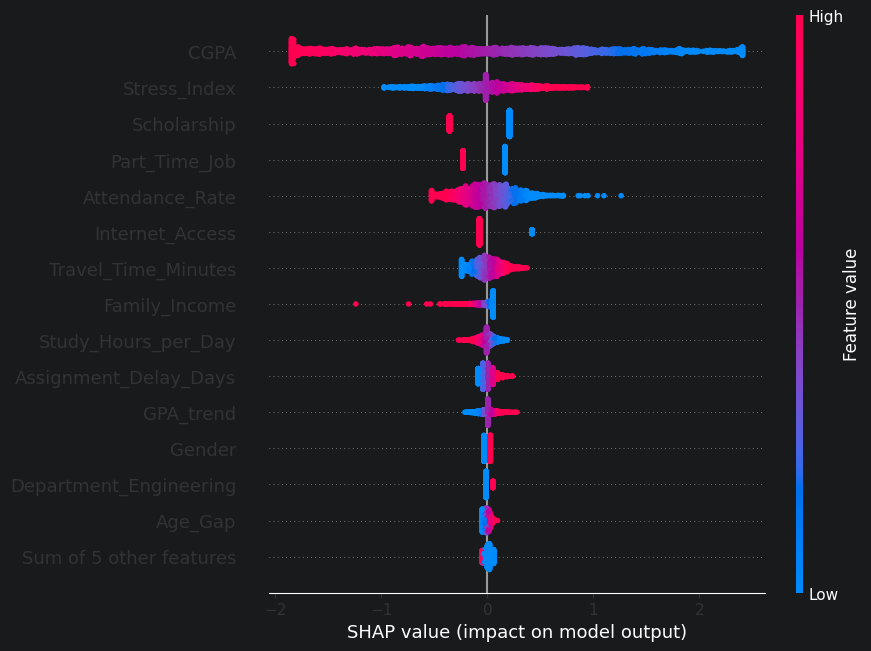

In [9]:
print("Počítám SHAP hodnoty... (tohle může chvilku trvat)")

# 1. Použijeme explicitně LinearExplainer (nejlepší pro Logistickou regresi)
explainer = shap.LinearExplainer(final_estimator, X_train_prep)
shap_values = explainer(X_test_prep)

# 2. 🚨 TRIK NA OPRAVU CHYBY: Převod na čistá desetinná čísla
shap_values.values = shap_values.values.astype(float)
shap_values.data = np.array(shap_values.data, dtype=float)

print("--- Globální důležitost proměnných (SHAP Summary Plot) ---")
# Nyní už to NumPy bez problému přechroustá
shap.plots.beeswarm(shap_values, max_display=15)

In [10]:
# Necháme model předpovědět pravděpodobnosti pro testovací data
probabilities = final_estimator.predict_proba(X_test_prep)[:, 1] # Index 1 je pravděpodobnost Dropoutu

# Najdeme studenty, kteří mají pravděpodobnost vyhazovu mezi 80 % a 90 %
risky_students_indices = [i for i, prob in enumerate(probabilities) if 0.80 <= prob <= 0.90]

# Vybereme hned toho prvního z naší rizikové skupiny
student_index = risky_students_indices[0]
vybrany_student = X_test_prep.iloc[student_index]
pravdepodobnost = probabilities[student_index]

print(f"🕵️‍♂️ Zvolen student na indexu: {student_index}")
print(f"Riziko vyhazovu podle modelu: {pravdepodobnost * 100:.1f} %")
print("\nJeho skutečné hodnoty:")
print(vybrany_student[vybrany_student != 0].head(10)) # Vypíše jen nenulové sloupce pro přehlednost

🕵️‍♂️ Zvolen student na indexu: 17
Riziko vyhazovu podle modelu: 85.9 %

Jeho skutečné hodnoty:
Family_Income         -0.083656
Study_Hours_per_Day   -2.100029
Stress_Index           0.277687
Age_Gap                1.162969
CGPA                  -1.611627
GPA_trend              0.502424
Department_Science          1.0
Gender                        1
Internet_Access               1
Attendance_Rate            87.6
Name: 2163, dtype: object



--- Rozpad rizika pro studenta č. 17 (SHAP Waterfall) ---


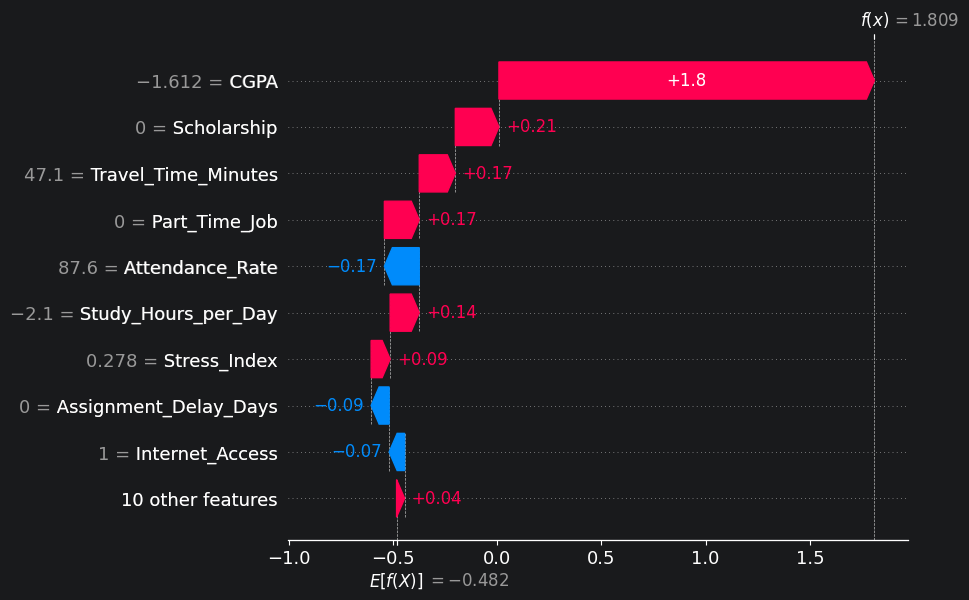

In [11]:
print(f"\n--- Rozpad rizika pro studenta č. {student_index} (SHAP Waterfall) ---")
# Ukážeme, co přesně posunulo jeho skóre od průměru až k těm jeho 85 %
shap.plots.waterfall(shap_values[student_index], max_display=10)


--- Analýza pomocí LIME (Lokální lidská pravidla) ---


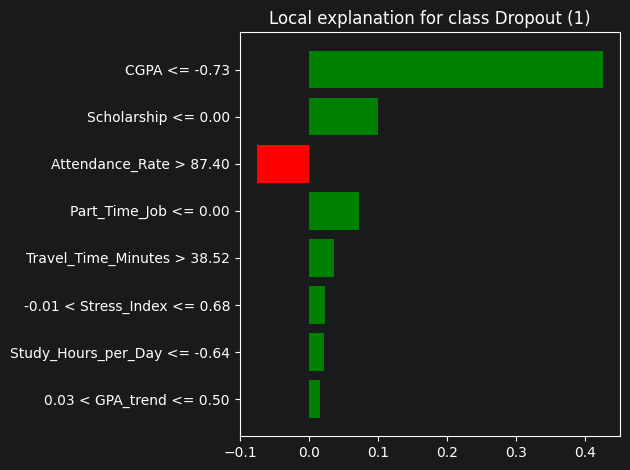

In [12]:
import lime
import lime.lime_tabular
from IPython.display import display, HTML # Zde si načteme ty správné, moderní dveře!

print("\n--- Analýza pomocí LIME (Lokální lidská pravidla) ---")

def predict_with_names(data_matrix):
    # Vezmeme holá data od LIME a uděláme z nich Pandas tabulku se správnými názvy
    df_temp = pd.DataFrame(data_matrix, columns=X_train_prep.columns)
    # Teprve tohle pošleme našemu modelu
    return final_estimator.predict_proba(df_temp)

# Inicializace LIME Explaineru
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_prep.values,
    feature_names=X_train_prep.columns.tolist(),
    class_names=['Dostuduje (0)', 'Dropout (1)'],
    mode='classification',
    random_state=42
)

# Vysvětlení našeho vybraného rizikového studenta
exp = lime_explainer.explain_instance(
    data_row=vybrany_student.values,
    predict_fn=predict_with_names,
    num_features=8 # Kolik nejlepších pravidel chceme ukázat
)

# 1. Necháme LIME vygenerovat čistý HTML kód (to umí bez chyby)
html_data = exp.as_html(show_table=True, show_all=False)

# 2. Vykreslíme to přes náš moderní import
display(HTML(html_data))

exp.as_pyplot_figure()
plt.tight_layout()
plt.show()